In [32]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms.v2 as T
from torchvision.datasets import ImageFolder

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import random

import flax
import flax.linen as nn
from flax.training import train_state

import optax

print("running on", jax.devices()[0])

running on TFRT_CPU_0


In [4]:
data_path = Path(r"C:\Users\bamilosin\Documents\datasets\vision\food vision data\pizza_steak_sushi-10%")

transforms = T.Compose([
    T.ToImage(),
    T.Resize((128,128)),
    T.ToDtype(torch.float)
])

train_dataset = ImageFolder(data_path / "train", transforms)
val_dataset = ImageFolder(data_path / "test", transforms)

## jax collate function
def numpy_collate(batch):
    if isinstance(batch[0], np.ndarray):
        return np.stack(batch)
    elif isinstance(batch[0], (tuple, list)):
        transposed = zip(*batch)
        return [numpy_collate(samples) for samples in transposed]
    else:
        return np.array(batch)

batch_size=64
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, collate_fn=numpy_collate)
val_dataloader = DataLoader(val_dataset, batch_size, shuffle=False, collate_fn=numpy_collate)

In [5]:
images, labels = next(iter(train_dataloader))

In [6]:
classes = train_dataset.classes
classes

['pizza', 'steak', 'sushi']

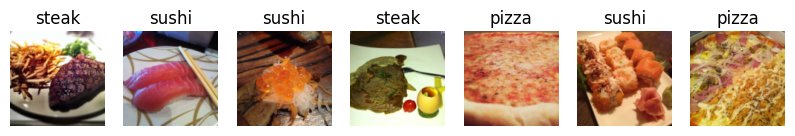

In [7]:
# plot images
samples = torch.randperm(len(images))[:7]

fig, axs = plt.subplots(nrows=1, ncols=7, figsize=(10,5))
for i, sample in enumerate(samples):
    img = images[sample].transpose(1,2,0).astype(np.uint8)
    axs[i].imshow(img)
    axs[i].set_title(classes[labels[sample]])
    axs[i].axis(False)

In [9]:
images[0].shape

(3, 128, 128)

In [124]:
class FoodClassifier(nn.Module):
    num_classes:int = 3
    num_feats:int = 32

    @nn.compact
    def __call__(self, x):
        batch_size = x.shape[0]
        x = nn.Conv(features=self.num_feats, kernel_size=(3,3), padding="SAME")(x)
        x = nn.relu(x)
        x = nn.Conv(features=self.num_feats, kernel_size=(3,3), padding="SAME")(x)
        x = x.reshape((batch_size, -1))
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=self.num_classes)(x)
        return x


In [125]:
model = FoodClassifier()
print(model)

FoodClassifier(
    # attributes
    num_classes = 3
    num_feats = 32
)


In [126]:
# initialize parameters
rng = random.PRNGKey(42)
rng, init_rng, input_rng = random.split(rng, 3)

# initialize input
input = random.normal(input_rng, (batch_size, 3, 128,128))

# init model
params = model.init(init_rng, input)
print(params)

{'params': {'Conv_0': {'kernel': Array([[[[-2.87163295e-02,  4.39333506e-02,  4.21497189e-02, ...,
          -2.18399819e-02,  1.35802990e-02,  2.79612932e-02],
         [-3.39639857e-02,  2.03579832e-02,  9.66580212e-03, ...,
          -5.50000230e-03,  2.49332469e-02, -6.38423637e-02],
         [-3.52451950e-02, -2.33942866e-02, -2.71861069e-02, ...,
          -6.95000589e-03, -4.71150270e-03, -6.17497712e-02],
         ...,
         [ 5.53194396e-02,  3.11429426e-02, -5.45614399e-02, ...,
          -4.22154404e-02,  1.04580885e-02, -3.17826159e-02],
         [-4.19068262e-02, -5.22376262e-02,  5.34609444e-02, ...,
          -8.43919348e-04, -1.02545437e-03,  3.73784937e-02],
         [-4.48981114e-02, -1.27752917e-02,  4.80365148e-03, ...,
           5.52362092e-02, -5.03320387e-03,  2.02004313e-02]],

        [[ 1.28715811e-02,  6.49738777e-03,  4.82298248e-02, ...,
          -1.46773914e-02,  3.50725986e-02,  1.59894340e-02],
         [-2.64512617e-02, -1.73024815e-02,  5.28615080

In [127]:
model.apply(params, input).shape

(64, 3)

In [128]:
# optimizer
optimizer = optax.adam(learning_rate=1e-3)

In [129]:
model_state = train_state.TrainState.create(apply_fn=model.apply,
                                     params=params,
                                     tx=optimizer)

In [130]:
def loss_and_accuracy(params, state, batch):
    images, labels = batch
    logits = state.apply_fn(params, images)

    loss = optax.softmax_cross_entropy_with_integer_labels(logits=logits, labels=labels).mean()
    accuracy = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    return loss, accuracy

loss_and_accuracy(params, model_state, next(iter(train_dataloader)))

(Array(99.27533, dtype=float32), Array(0.296875, dtype=float32))

In [131]:
# train step
@jax.jit
def train_step(state, batch):
    grad_fn = jax.value_and_grad(loss_and_accuracy,
                                 argnums=0,
                                 has_aux=True)

    (loss, acc), grads = grad_fn(state.params, state, batch)

    # update params
    state = state.apply_gradients(grads=grads)

    return state, loss, acc

In [132]:
# for evaluation
@jax.jit
def eval_step(state, batch):
    loss, acc = loss_and_accuracy(state.params, state, batch)
    return loss, acc

In [133]:
def train_model(state, train_dataloader, test_dataloader, epochs):

    history = {
        "train_loss":[],
        "train_acc":[],
        "val_loss":[],
        "val_acc":[]
    }
    for epoch in range(epochs):
        for batch in train_dataloader:
            state, train_loss, train_acc = train_step(state, batch)

        # evaluate model
        for batch in val_dataloader:
            val_loss, val_acc = eval_step(state, batch)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"{epoch+1}/{epochs} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.2f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.2f}")


    return state, history

In [134]:
trained_model_state = train_model(model_state, train_dataloader, val_dataloader, epochs=200)

1/200 | train_loss: 2324.8733 | train_acc: 0.28 | val_loss: 645.8214 | val_acc: 0.00
2/200 | train_loss: 75.5084 | train_acc: 0.39 | val_loss: 69.8730 | val_acc: 0.08
3/200 | train_loss: 25.6464 | train_acc: 0.19 | val_loss: 12.1375 | val_acc: 0.08
4/200 | train_loss: 8.5042 | train_acc: 0.36 | val_loss: 0.9959 | val_acc: 0.67
5/200 | train_loss: 4.9033 | train_acc: 0.31 | val_loss: 2.4565 | val_acc: 0.25
6/200 | train_loss: 1.5589 | train_acc: 0.36 | val_loss: 2.2788 | val_acc: 0.00
7/200 | train_loss: 1.1124 | train_acc: 0.44 | val_loss: 1.7760 | val_acc: 0.17
8/200 | train_loss: 1.0050 | train_acc: 0.42 | val_loss: 1.6799 | val_acc: 0.17
9/200 | train_loss: 0.8145 | train_acc: 0.58 | val_loss: 1.6781 | val_acc: 0.25
10/200 | train_loss: 0.7161 | train_acc: 0.67 | val_loss: 1.7814 | val_acc: 0.17
11/200 | train_loss: 0.7852 | train_acc: 0.67 | val_loss: 1.7177 | val_acc: 0.17
12/200 | train_loss: 0.8323 | train_acc: 0.61 | val_loss: 1.4759 | val_acc: 0.25
13/200 | train_loss: 0.8361 

dtype('int64')